In [1]:
# ライブラリインポート
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import warnings
import os
warnings.filterwarnings('ignore')

# キャッシュ設定
cache_folder = './cache'
if not os.path.exists(cache_folder):
    os.makedirs(cache_folder)
fastf1.Cache.enable_cache(cache_folder)

print("2025年F1セットアップ効率分析（高度版）")
print("=" * 60)

2025年F1セットアップ効率分析（高度版）


In [2]:
# 1. 2025年シーズンスケジュール定義
def get_2025_schedule():
    """2025年F1シーズンの24レースを定義（スプリント開催地を正確に修正）"""
    races = [
        {"Round": 1, "Name": "Australian Grand Prix", "Format": "conventional"},
        {"Round": 2, "Name": "Chinese Grand Prix", "Format": "sprint"},      # スプリント
        {"Round": 3, "Name": "Japanese Grand Prix", "Format": "conventional"},
        {"Round": 4, "Name": "Bahrain Grand Prix", "Format": "conventional"},
        {"Round": 5, "Name": "Saudi Arabian Grand Prix", "Format": "conventional"},
        {"Round": 6, "Name": "Miami Grand Prix", "Format": "sprint"},        # スプリント
        {"Round": 7, "Name": "Emilia Romagna Grand Prix", "Format": "conventional"},
        {"Round": 8, "Name": "Monaco Grand Prix", "Format": "conventional"},
        {"Round": 9, "Name": "Spanish Grand Prix", "Format": "conventional"},
        {"Round": 10, "Name": "Canadian Grand Prix", "Format": "conventional"},
        {"Round": 11, "Name": "Austrian Grand Prix", "Format": "conventional"}, 
        {"Round": 12, "Name": "British Grand Prix", "Format": "conventional"},
        {"Round": 13, "Name": "Belgian Grand Prix", "Format": "sprint"},      # スプリント
        {"Round": 14, "Name": "Hungarian Grand Prix", "Format": "conventional"},
        {"Round": 15, "Name": "Dutch Grand Prix", "Format": "conventional"},
        {"Round": 16, "Name": "Italian Grand Prix", "Format": "conventional"},
        {"Round": 17, "Name": "Azerbaijan Grand Prix", "Format": "conventional"},
        {"Round": 18, "Name": "Singapore Grand Prix", "Format": "conventional"},
        {"Round": 19, "Name": "United States Grand Prix", "Format": "sprint"}, # スプリント
        {"Round": 20, "Name": "Mexico City Grand Prix", "Format": "conventional"},
        {"Round": 21, "Name": "São Paulo Grand Prix", "Format": "sprint"},    
        {"Round": 22, "Name": "Las Vegas Grand Prix", "Format": "conventional"},
        {"Round": 23, "Name": "Qatar Grand Prix", "Format": "sprint"},        # スプリント
        {"Round": 24, "Name": "Abu Dhabi Grand Prix", "Format": "conventional"}
    ]
    return pd.DataFrame(races)

# ポイントシステム定義
def get_points_for_position(position):
    """順位からポイントを計算"""
    points_system = {
        1: 25, 2: 18, 3: 15, 4: 12, 5: 10,
        6: 8, 7: 6, 8: 4, 9: 2, 10: 1
    }
    return points_system.get(int(position), 0)

# 前年チームランク
def get_initial_team_rankings():
    """2024年の最終チームランキング（初期値として使用）"""
    return {
        'McLaren': 1, 'Ferrari': 2, 'Red Bull Racing': 3, 'Mercedes': 4,
        'Aston Martin': 5, 'Alpine': 6, 'Haas F1 Team': 7, 'Racing Bulls': 8,
        'Williams': 9, 'Kick Sauber': 10
    }

# === ハイブリッド方式：動的チームランク + チーム内序列 ===

def calculate_dynamic_team_rankings_with_intra_team(all_race_results, current_round):
    """
    動的チームランク + チーム内序列を考慮した期待順位計算（ハイブリッド方式）
    
    Args:
        all_race_results: これまでのレース結果 {round: results_df}
        current_round: 現在のレース番号
    
    Returns:
        {driver_name: expected_position} の辞書
    """
    
    # 1. 動的チームランク計算（直近5レース方式）
    team_points = {}
    
    # ここで start_round を初期化（エラー回避のため）
    start_round = max(1, current_round - 4)

    if current_round == 1:
        # Round 1: 前年のチームランキングを使用
        initial_rankings = get_initial_team_rankings()
        for team, rank in initial_rankings.items():
            team_points[team] = (11 - rank) * 50  # 適当なポイントを付与
    else:
        # Round 2以降: 直近5レースのポイントを計算
        # print(f"    チーム実力計算: Round {start_round}-{current_round-1}の直近5レースを使用")
        
        for round_num in range(start_round, current_round):
            if round_num not in all_race_results:
                continue
                
            results = all_race_results[round_num]
            for _, driver in results.iterrows():
                team_name = driver['TeamName']
                position = driver['Position']
                points = get_points_for_position(position)
                
                if team_name not in team_points:
                    team_points[team_name] = 0
                team_points[team_name] += points
    
    # チームをポイント順にソートしてランク付け
    sorted_teams = sorted(team_points.items(), key=lambda x: x[1], reverse=True)
    team_rankings = {team: rank + 1 for rank, (team, _) in enumerate(sorted_teams)}
    
    # 2. ドライバーごとの直近5レースポイントを計算
    driver_points = {}
    driver_teams = {}
    
    # Round 1の場合はこのループは range(1, 1) となり実行されないので安全
    for round_num in range(start_round, current_round):
        if round_num not in all_race_results:
            continue
            
        results = all_race_results[round_num]
        for _, driver in results.iterrows():
            driver_name = driver['Abbreviation']
            team_name = driver['TeamName']
            position = driver['Position']
            points = get_points_for_position(position)
            
            if driver_name not in driver_points:
                driver_points[driver_name] = 0
                driver_teams[driver_name] = team_name
            driver_points[driver_name] += points
    
    # Round 1の場合、driver_teamsが空になる可能性があるため、all_race_resultsから取得を試みる
    if current_round == 1 and not driver_teams:
        # 予選結果があればそこから所属チーム情報を取得
        if current_round in all_race_results:
             results = all_race_results[current_round]
             for _, driver in results.iterrows():
                 driver_teams[driver['Abbreviation']] = driver['TeamName']

    # 3. チーム内でドライバーを序列付け（直近5レースのポイント）
    team_driver_rankings = {}
    
    for team_name in team_rankings.keys():
        # このチームのドライバーを抽出
        team_drivers = {}
        for driver_name, team in driver_teams.items():
            if team == team_name:
                team_drivers[driver_name] = driver_points.get(driver_name, 0)
        
        # ポイント順にソートして序列付け
        sorted_drivers = sorted(team_drivers.items(), key=lambda x: x[1], reverse=True)
        team_driver_rankings[team_name] = {
            driver: rank + 1 for rank, (driver, _) in enumerate(sorted_drivers)
        }
    
    # 4. 期待順位計算（ハイブリッド方式）
    expected_positions = {}
    
    for driver_name, team_name in driver_teams.items():
        # チームランク
        team_rank = team_rankings.get(team_name, 10)
        
        # チーム内序列
        intra_team_rank = team_driver_rankings.get(team_name, {}).get(driver_name, 2)
        
        # チーム実力値 = (チームランク - 1) × 2 + チーム内序列
        team_performance_pos = (team_rank - 1) * 2 + intra_team_rank
        
        # ドライバー実力（全ドライバー中の順位）
        all_drivers_sorted = sorted(driver_points.items(), key=lambda x: x[1], reverse=True)
        driver_rank = next((rank + 1 for rank, (driver, _) in enumerate(all_drivers_sorted) 
                          if driver == driver_name), 20)
        
        # 期待順位 = ドライバー実力 × 0.3 + チーム実力 × 0.7
        expected_position = (driver_rank * 0.3) + (team_performance_pos * 0.7)
        
        expected_positions[driver_name] = {
            'expected_pos': expected_position,
            'team_rank': team_rank,
            'intra_team_rank': intra_team_rank,
            'team_performance_pos': team_performance_pos,
            'driver_rank': driver_rank,
            'team_points': team_points.get(team_name, 0),
            'driver_points': driver_points.get(driver_name, 0),
            'round_range': f"{start_round}-{current_round-1}"
        }
    
    return expected_positions

def calculate_expected_position(team_name, team_rankings):
    """旧バージョン（互換性のため残す）"""
    team_rank = team_rankings.get(team_name, 10)
    return team_rank * 2  # 簡単な計算

print("ハイブリッド方式のチーム実力計算関数を修正・定義しました")

ハイブリッド方式のチーム実力計算関数を修正・定義しました


In [3]:
# 2. アタックラップ計算関数の修正
def count_attack_laps(fp_laps):
    """FPセッションでのアタックラップをドライバーごとにカウントして辞書で返す"""
    if fp_laps is None or fp_laps.empty:
        return {} # 空の辞書を返す
    
    driver_lap_counts = {} # { 'VER': 15, 'TSU': 12, ... } の形にする
    
    for driver in fp_laps['Driver'].unique():
        driver_laps = fp_laps[fp_laps['Driver'] == driver].copy()
        
        # --- (中略：タイヤフィルタや107%ルールのロジックはそのまま) ---
        if 'Compound' not in driver_laps.columns:
            continue
        
        soft_medium_laps = driver_laps[driver_laps['Compound'].isin(['SOFT', 'MEDIUM', 'HARD'])].copy()
        if soft_medium_laps.empty:
            driver_lap_counts[driver] = 0
            continue
            
        valid_laps = soft_medium_laps[soft_medium_laps['LapTime'].notna()].copy()
        if valid_laps.empty:
            driver_lap_counts[driver] = 0
            continue
            
        driver_best = valid_laps['LapTime'].min()
        threshold_107 = driver_best * 1.07
        
        attack_laps = valid_laps[valid_laps['LapTime'] <= threshold_107].copy()
        
        if len(attack_laps) > 0:
            median_time = attack_laps['LapTime'].median()
            attack_laps = attack_laps[attack_laps['LapTime'] <= median_time * 1.2]
        
        # 辞書に保存
        driver_lap_counts[driver] = len(attack_laps)
    
    return driver_lap_counts

# 3. レースデータ取得関数
def get_race_data(year, race_name, race_format):
    """特定レースのデータを取得"""
    print(f"\nProcessing: {race_name} ({race_format})")
    
    try:
        # スプリントレースと通常レースで取得セッションを変更
        if race_format == 'sprint':
            # スプリントレース：FP1 + スプリント予選
            sessions_to_load = ['FP1', 'Sprint Qualifying']
            attack_session = 'FP1'
            quali_session = 'Sprint Qualifying'
        else:
            # 通常レース：FP2 + FP3 + 本予選
            sessions_to_load = ['FP2', 'FP3', 'Qualifying']
            attack_session = ['FP2', 'FP3']  # 両方の合計
            quali_session = 'Qualifying'
        
        race_data = {}
        
        # セッションデータを取得
        for session_name in sessions_to_load:
            try:
                print(f"  Loading {session_name}...")
                session = fastf1.get_session(year, race_name, session_name)
                session.load()
                
                if session_name == quali_session:
                    # 予選結果
                    race_data['qualifying_results'] = session.results.copy()
                else:
                    # FPセッション
                    if 'fp_sessions' not in race_data:
                        race_data['fp_sessions'] = {}
                    race_data['fp_sessions'][session_name] = session.laps.copy()
                    
                print(f"    {session_name}: {len(session.laps)} laps loaded")
                
            except Exception as e:
                print(f"    Error loading {session_name}: {e}")
                if session_name == quali_session:
                    race_data['qualifying_results'] = None
                else:
                    if 'fp_sessions' not in race_data:
                        race_data['fp_sessions'] = {}
                    race_data['fp_sessions'][session_name] = None
        
        return race_data
        
    except Exception as e:
        print(f"Error processing {race_name}: {e}")
        return None

In [4]:
# 6. メイン分析関数（ハイブリッド方式対応）
def analyze_season_setup_efficiency(year=2025):
    """シーズン全体のセットアップ効率を分析（ハイブリッド方式）"""
    
    # スケジュール取得
    schedule = get_2025_schedule()
    print(f"2025年F1シーズン: {len(schedule)} レース")
    
    # データ格納用
    all_race_results = {}  # レース結果を蓄積
    pooled_data = []       # 全データをプール
    
    # 各レースを処理
    for _, race in schedule.iterrows():
        round_num = race['Round']
        race_name = race['Name']
        race_format = race['Format']
        
        print(f"\n処理中: Round {round_num} - {race_name} ({race_format})")
        
        # レースデータ取得
        race_data = get_race_data(year, race_name, race_format)
        
        if race_data is None:
            print(f"  → スキップ: データ取得失敗")
            continue
        
        # 予選結果を保存
        if race_data['qualifying_results'] is not None:
            all_race_results[round_num] = race_data['qualifying_results']
        else:
            print(f"  → スキップ: 予選結果なし")
            continue
        
        # ハイブリッド方式：動的チームランク + チーム内序列
        expected_positions = calculate_dynamic_team_rankings_with_intra_team(all_race_results, round_num)
        
        print(f"  → 期待順位計算完了: {len(expected_positions)} ドライバー")
        
        # アタックラップ数計算（辞書を受け取る）
        driver_attack_counts = {}
        
        if race_format == 'sprint':
            # スプリント：FP1のみ
            fp1_laps = race_data['fp_sessions'].get('FP1')
            driver_attack_counts = count_attack_laps(fp1_laps)
        else:
            # 通常：FP2 + FP3
            fp2_laps = race_data['fp_sessions'].get('FP2')
            fp3_laps = race_data['fp_sessions'].get('FP3')
            counts_fp2 = count_attack_laps(fp2_laps)
            counts_fp3 = count_attack_laps(fp3_laps)
            
            # FP2とFP3を合算する
            all_drivers = set(list(counts_fp2.keys()) + list(counts_fp3.keys()))
            for drv in all_drivers:
                driver_attack_counts[drv] = counts_fp2.get(drv, 0) + counts_fp3.get(drv, 0)
        
        print(f"  → アタックラップ取得: {len(driver_attack_counts)} ドライバー")
        
        # 予選結果からドライバーごとのデータを抽出
        quali_results = race_data['qualifying_results']
        if quali_results is not None:
            for _, driver in quali_results.iterrows():
                driver_name = driver['Abbreviation']
                team_name = driver['TeamName']
                quali_position = driver['Position']
                
                # ハイブリッド方式の期待順位を取得
                expected_data = expected_positions.get(driver_name, {})
                expected_pos = expected_data.get('expected_pos', 10)
                
                # そのドライバー固有の周回数を辞書から取得
                my_attack_laps = driver_attack_counts.get(driver_name, 0)
                
                # データをプールに追加
                pooled_data.append({
                    'Round': round_num,
                    'RaceName': race_name,
                    'Format': race_format,
                    'Driver': driver_name,
                    'Team': team_name,
                    'TeamRank_Dynamic': expected_data.get('team_rank', 10),
                    'IntraTeamRank': expected_data.get('intra_team_rank', 2),
                    'TeamPerformancePos': expected_data.get('team_performance_pos', 10),
                    'DriverRank': expected_data.get('driver_rank', 20),
                    'TeamPoints': expected_data.get('team_points', 0),
                    'DriverPoints': expected_data.get('driver_points', 0),
                    'AttackLaps': my_attack_laps,
                    'QualiPos': quali_position,
                    'ExpectedPos': expected_pos,
                    'PositionDeviation': quali_position - expected_pos
                })
        
        print(f"  → データ追加: {len(quali_results)} ドライバー分")
    
    # DataFrameに変換
    df = pd.DataFrame(pooled_data)
    
    print(f"\n=== 分析完了 ===")
    print(f"総データ件数: {len(df)}")
    print(f"対象レース数: {df['Round'].nunique()}")
    print(f"対象ドライバー数: {df['Driver'].nunique()}")
    
    # 基本統計
    if not df.empty:
        print(f"\n基本統計:")
        print(f"  AttackLaps範囲: {df['AttackLaps'].min()} - {df['AttackLaps'].max()}")
        print(f"  AttackLaps平均: {df['AttackLaps'].mean():.1f}")
        print(f"  QualiPos範囲: {df['QualiPos'].min()} - {df['QualiPos'].max()}")
        print(f"  QualiPos平均: {df['QualiPos'].mean():.1f}")
        print(f"  ExpectedPos範囲: {df['ExpectedPos'].min():.1f} - {df['ExpectedPos'].max():.1f}")
        print(f"  PositionDeviation範囲: {df['PositionDeviation'].min():.1f} - {df['PositionDeviation'].max():.1f}")
        
        # 相関係数
        if df['AttackLaps'].nunique() > 1 and df['QualiPos'].nunique() > 1:
            corr_original = df['AttackLaps'].corr(df['QualiPos'])
            corr_expected = df['AttackLaps'].corr(df['ExpectedPos'])
            corr_deviation = df['AttackLaps'].corr(df['PositionDeviation'])
            
            print(f"\n相関係数:")
            print(f"  AttackLaps vs QualiPos: {corr_original:.3f}")
            print(f"  AttackLaps vs ExpectedPos: {corr_expected:.3f}")
            print(f"  AttackLaps vs PositionDeviation: {corr_deviation:.3f}")
        
        # フォーマット別統計
        print(f"\nフォーマット別統計:")
        conventional = df[df['Format'] == 'conventional']
        sprint = df[df['Format'] == 'sprint']
        
        print(f"  通常レース: {len(conventional)}件 ({conventional['Round'].nunique()}レース)")
        print(f"  スプリントレース: {len(sprint)}件 ({sprint['Round'].nunique()}レース)")
        
        # AttackLaps = 0のレースを確認
        zero_attack_races = df[df['AttackLaps'] == 0]['Round'].unique()
        if len(zero_attack_races) > 0:
            print(f"\nAttackLaps = 0のレース: {sorted(zero_attack_races)}")
    
    return df

print("ハイブリッド方式のメイン分析関数を定義しました")

ハイブリッド方式のメイン分析関数を定義しました


In [5]:
# 7. 1レースごとの相関分析関数（修正版：表現を「相関」に統一）
def analyze_race_by_race_correlation(df):
    """1レースごとの相関係数を分析して可視化（詳細テキスト出力あり）"""
    
    if df.empty:
        print("データがありません")
        return pd.DataFrame()
    
    # 日本語フォント設定（環境に合わせてください。エラーが出る場合はコメントアウト）
    # plt.rcParams['font.family'] = 'Hiragino Sans' 
    
    print("\n=== レースごとの相関分析詳細（AttackLaps vs PositionDeviation） ===")
    print("※ 負の相関（マイナス）: アタック数が多いほど、偏差がマイナス（順位が良い）になる傾向")
    print("※ 正の相関（プラス）  : アタック数が多いほど、偏差がプラス（順位が悪い）になる傾向")
    
    # 各レースの相関係数を計算
    race_correlations = []
    
    for round_num in sorted(df['Round'].unique()):
        race_data = df[df['Round'] == round_num]
        
        # データ点数が少なすぎる、または値が一定で相関計算できない場合はスキップ
        if len(race_data) < 3 or race_data['AttackLaps'].nunique() <= 1 or race_data['PositionDeviation'].nunique() <= 1:
            continue
            
        corr = race_data['AttackLaps'].corr(race_data['PositionDeviation'])
        race_name = race_data['RaceName'].iloc[0]
        race_format = race_data['Format'].iloc[0]
        
        race_correlations.append({
            'Round': round_num,
            'RaceName': race_name,
            'Format': race_format,
            'Correlation': corr,
            'Drivers': len(race_data)
        })
    
    # DataFrame作成
    corr_df = pd.DataFrame(race_correlations)
    
    if corr_df.empty:
        print("相関を計算できるレースがありませんでした")
        return pd.DataFrame()

    # === テキストでの詳細出力 ===
    
    # 1. 負の相関が強いレース（アタック多 → 好成績 の傾向）
    print(f"\n【負の相関が強かったレース Top 5】 (アタック多→好成績傾向)")
    strongest = corr_df.sort_values('Correlation', ascending=True).head(5)
    for _, row in strongest.iterrows():
        print(f"  Rd.{row['Round']:2d} {row['RaceName'][:15]}... : 相関 {row['Correlation']:.3f} ({row['Format']})")
        
    # 2. 正の相関が強いレース（アタック多 → 成績低下/関係なし の傾向）
    print(f"\n【正の相関が強かったレース Top 5】 (アタック多→成績低下傾向)")
    weakest = corr_df.sort_values('Correlation', ascending=False).head(5)
    for _, row in weakest.iterrows():
        print(f"  Rd.{row['Round']:2d} {row['RaceName'][:15]}... : 相関 {row['Correlation']:.3f} ({row['Format']})")
        
    # 3. 全レース相関一覧（判定コメントを修正）
    print(f"\n【全レース相関一覧】")
    print(f"{'Round':<6} {'Race Name':<20} {'Format':<12} {'Corr':<8} {'判定'}")
    print("-" * 65)
    for _, row in corr_df.sort_values('Round').iterrows():
        # 判定コメント（効果→相関 に変更）
        if row['Correlation'] < -0.2: jud = "◎ 負の相関(強)"
        elif row['Correlation'] < -0.1: jud = "○ 負の相関(弱)"
        elif row['Correlation'] > 0.2:  jud = "▲ 正の相関"
        else: jud = "- 相関なし"
        
        print(f"{row['Round']:<6d} {row['RaceName'][:18]:<20} {row['Format']:<12} {row['Correlation']:>6.3f}   {jud}")

    # === グラフ描画 ===
    try:
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # グラフ1: 推移
        ax1 = axes[0]
        ax1.plot(corr_df['Round'], corr_df['Correlation'], 'o-', label='Correlation')
        ax1.axhline(0, color='black', linestyle='--')
        ax1.set_title('Correlation by Round (Negative = Attack correlates with Performance)')
        ax1.set_xlabel('Round')
        ax1.set_ylabel('Correlation Coefficient')
        ax1.grid(True, alpha=0.5)
        
        # グラフ2: 分布
        ax2 = axes[1]
        ax2.hist(corr_df['Correlation'], bins=10, color='skyblue', edgecolor='black', alpha=0.7)
        ax2.axvline(0, color='black', linestyle='--')
        ax2.set_title('Distribution of Correlations')
        ax2.set_xlabel('Correlation Coefficient')
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"グラフ描画エラー（データ出力は完了しています）: {e}")
    
    return corr_df

print("修正完了: 相関分析関数の表現を統計用語（相関）に統一しました")

修正完了: 相関分析関数の表現を統計用語（相関）に統一しました


In [6]:
def create_simple_analysis_plot(df):
    """シンプルでわかりやすい全体分析グラフを作成（散布図1枚版）"""
    
    if df.empty:
        print("データがありません")
        return
    
    # フォント設定
    plt.rcParams['font.family'] = 'Hiragino Sans' # 環境に合わせて変更してください
    plt.rcParams['axes.unicode_minus'] = False
    
    print("=== シンプル全体分析グラフ（偏差ベース）作成中... ===")
    
    # 1つの大きなグラフを作成
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # === データのプロット ===
    conventional = df[df['Format'] == 'conventional']
    sprint = df[df['Format'] == 'sprint']
    
    # 通常レース
    ax.scatter(conventional['AttackLaps'], conventional['PositionDeviation'], 
               alpha=0.6, s=80, color='#1f77b4', label='通常レース', edgecolors='white')
    
    # スプリント（あれば）
    if not sprint.empty:
        ax.scatter(sprint['AttackLaps'], sprint['PositionDeviation'], 
                   alpha=0.6, s=80, color='#d62728', label='スプリント', marker='s', edgecolors='white')
    
    # === 客観的な基準線 ===
    # 偏差0のライン（期待順位どおりの結果）
    ax.axhline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # === 相関係数の表示 ===
    corr = df['AttackLaps'].corr(df['PositionDeviation'])
    # グラフの邪魔にならない右上に配置
    text_str = f'相関係数: {corr:.3f}\n(正=アタック多いほど順位低下\n 負=アタック多いほど順位向上)'
    ax.text(0.95, 0.95, text_str, transform=ax.transAxes, fontsize=10,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='#cccccc'))
    
    # === 装飾 ===
    ax.set_title('2025年F1セットアップ効率分析：アタック数 vs 期待値偏差', fontsize=14, fontweight='bold')
    ax.set_xlabel('アタックラップ数 (練習量)', fontsize=12)
    ax.set_ylabel('期待順位偏差 (マイナスが良い)', fontsize=12)
    
    # Y軸を反転（マイナス＝好成績 を上にするのが一般的）
    ax.invert_yaxis()
    
    # グリッドを見やすく
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend(loc='lower left', framealpha=0.9)
    
    plt.tight_layout()
    
    # 画像として保存（高画質）
    plt.savefig('simple_scatter_plot.png', dpi=300)
    plt.show()

print("修正完了：シンプルで客観的な散布図関数を定義しました")

修正完了：シンプルで客観的な散布図関数を定義しました


In [7]:
# 9. ドライバー別セットアップ効率分析
def analyze_driver_setup_efficiency(df):
    """ドライバーごとのセットアップ効率（周回数 vs パフォーマンス）を分析"""
    
    if df.empty:
        print("データがありません")
        return

    # 日本語フォント設定
    plt.rcParams['font.family'] = 'Hiragino Sans'
    plt.rcParams['axes.unicode_minus'] = False
    
    print("=== ドライバー別セットアップ効率分析 ===")
    
    # ドライバーごとの集計
    driver_stats = df.groupby(['Driver', 'Team']).agg({
        'AttackLaps': 'mean',          # 平均アタックラップ数
        'PositionDeviation': 'mean',   # 平均順位偏差（マイナスが良い）
        'QualiPos': 'mean',            # 平均予選順位
        'Round': 'count'               # データ数（参戦数）
    }).reset_index()
    
    # データ数が極端に少ないドライバー（代役など）を除外（例: 3戦未満）
    driver_stats = driver_stats[driver_stats['Round'] >= 3]
    
    print(f"分析対象ドライバー数: {len(driver_stats)}")
    
    # === グラフ作成 ===
    fig, ax = plt.subplots(figsize=(14, 10))
    
    # 散布図プロット
    # X軸: 平均アタックラップ数
    # Y軸: 平均順位偏差（予選順位 - 期待順位）※低い（マイナス）ほど良い
    
    x = driver_stats['AttackLaps']
    y = driver_stats['PositionDeviation']
    
    # チームごとに色分けするためのカラーマップ
    unique_teams = driver_stats['Team'].unique()
    colors = plt.cm.tab20(range(len(unique_teams)))
    team_color_map = dict(zip(unique_teams, colors))
    
    for team in unique_teams:
        team_data = driver_stats[driver_stats['Team'] == team]
        ax.scatter(team_data['AttackLaps'], team_data['PositionDeviation'], 
                   s=150, alpha=0.8, 
                   label=team, color=team_color_map[team], edgecolors='white', linewidth=1.5)
    
    # ドライバー名を表示
    texts = []
    for i, row in driver_stats.iterrows():
        texts.append(ax.text(row['AttackLaps'], row['PositionDeviation'], row['Driver'], 
                             fontsize=9, fontweight='bold'))
    
    # 基準線（平均値）
    avg_laps = x.mean()
    ax.axvline(x=avg_laps, color='gray', linestyle='--', alpha=0.5, label='平均周回数')
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.3, label='期待通り (偏差0)')
    
    # 象限の説明エリアを追加
    # 左下（周回少ない & 成績良い）
    ax.text(x.min(), y.min(), '少ない周回で好成績', 
            ha='left', va='bottom', fontsize=12, color='green', 
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='green'))
    
    # 右下（周回多い & 成績良い）
    ax.text(x.max(), y.min(), '走り込んで好成績', 
            ha='right', va='bottom', fontsize=12, color='blue',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='blue'))
            
    # 左上（周回少ない & 成績悪い）
    ax.text(x.min(), y.max(), '', 
            ha='left', va='top', fontsize=12, color='orange',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='orange'))

    # 右上（周回多い & 成績悪い）
    ax.text(x.max(), y.max(), '', 
            ha='right', va='top', fontsize=12, color='red',
            bbox=dict(facecolor='white', alpha=0.7, edgecolor='red'))
    
    ax.set_title('ドライバー別セットアップ特性マップ (2025シーズン)', fontsize=16, fontweight='bold')
    ax.set_xlabel('平均アタックラップ数 (練習走行)', fontsize=12)
    ax.set_ylabel('平均パフォーマンス偏差 (予選順位 - チーム期待値)', fontsize=12)
    ax.invert_yaxis()  # Y軸を反転（下がマイナス＝良い）
    ax.grid(True, alpha=0.3)
    ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Team')
    
    # 重なり回避（adjustTextがあれば使うが、標準ライブラリのみで行くため簡易表示）
    plt.tight_layout()
    plt.show()
    
    # === データテーブル表示 ===
    print("\n=== ドライバー別詳細データ（効率順） ===")
    # 偏差が小さい順（成績が良い順）にソート
    summary = driver_stats.sort_values('PositionDeviation')[['Driver', 'Team', 'AttackLaps', 'QualiPos', 'PositionDeviation']]
    summary.columns = ['Driver', 'Team', '平均アタック数', '平均予選順位', '平均偏差(低いほど良)']
    print(summary.round(2).to_string(index=False))

print("ドライバー別分析関数を定義しました")

ドライバー別分析関数を定義しました


core           INFO 	Loading data for Australian Grand Prix - Practice 2 [v3.7.0]
req            INFO 	No cached data found for session_info. Loading data...
_api           INFO 	Fetching session info data...


=== メイン分析開始（真の完全版） ===
analyze_season_setup_efficiency() を実行中...
2025年F1シーズン: 24 レース

処理中: Round 1 - Australian Grand Prix (conventional)

Processing: Australian Grand Prix (conventional)
  Loading FP2...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

    FP2: 552 laps loaded
  Loading FP3...


req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
_api           INFO 	Parsing timing data...
req            INFO 	Data has been written to cache!
req            INFO 	No cached data found for timing_app_data. Loading data...
_api           INFO 	Fetching timing app data...
req            INFO 	Data has been written to

...

    Error loading FP2: The data you are trying to access has not been loaded yet. See `Session.load`
  Loading FP3...


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
logger 

    Error loading FP3: The data you are trying to access has not been loaded yet. See `Session.load`
  Loading Qualifying...


logger      WARNING 	Failed to load session info data!
req            INFO 	No cached data found for driver_info. Loading data...
_api           INFO 	Fetching driver list...
core        WARNING 	Failed to load extended driver information!
logger      WARNING 	Failed to load result data from Ergast!
core        WARNING 	No result data for this session available on Ergast! (This is expected for recent sessions)
core        WARNING 	Failed to load driver list and session results!
req            INFO 	No cached data found for session_status_data. Loading data...
_api           INFO 	Fetching session status data...
logger      WARNING 	Failed to load session status data!
req            INFO 	No cached data found for track_status_data. Loading data...
_api           INFO 	Fetching track status data...
logger      WARNING 	Failed to load track status data!
req            INFO 	No cached data found for _extended_timing_data. Loading data...
_api           INFO 	Fetching timing data...
logger 

    Error loading Qualifying: The data you are trying to access has not been loaded yet. See `Session.load`
  → スキップ: 予選結果なし

=== 分析完了 ===
総データ件数: 320
対象レース数: 16
対象ドライバー数: 21

基本統計:
  AttackLaps範囲: 0 - 30
  AttackLaps平均: 13.0
  QualiPos範囲: 1.0 - 20.0
  QualiPos平均: 10.5
  ExpectedPos範囲: 1.0 - 20.0
  PositionDeviation範囲: -13.4 - 15.1

相関係数:
  AttackLaps vs QualiPos: 0.038
  AttackLaps vs ExpectedPos: 0.077
  AttackLaps vs PositionDeviation: -0.044

フォーマット別統計:
  通常レース: 260件 (13レース)
  スプリントレース: 60件 (3レース)

AttackLaps = 0のレース: [np.int64(1)]

✅ 分析完了！

=== 全体相関分析結果 ===
相関係数: -0.044
--------------------------------------------------
⚪ 判定：【関係なし】 (無相関)
--------------------------------------------------

=== レースごとの傾向 Top 5 ===

【あなたの直感が正しかったレース Top 5】 (アタック少→好成績)
               Race Name     Corr     判定
        Miami Grand Prix 0.279255 ▲ 正の相関
      Belgian Grand Prix 0.269190 ▲ 正の相関
      Italian Grand Prix 0.192819 - 相関なし
        Dutch Grand Prix 0.179706 - 相関なし
Saudi Arabian Grand Prix 0.14709

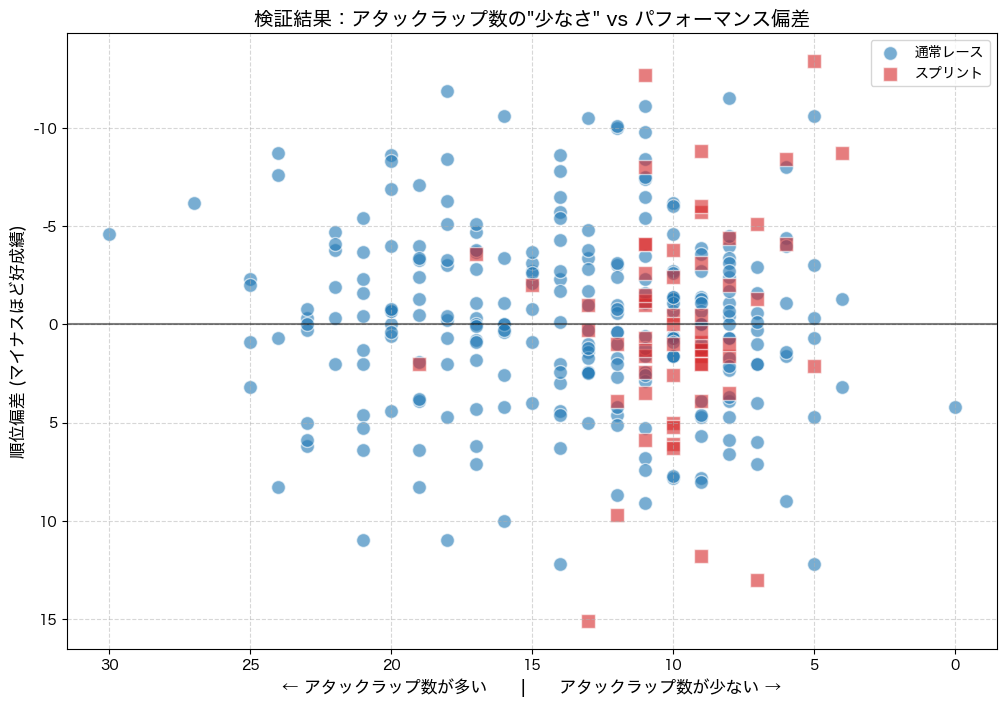

=== 分析完了 ===


In [8]:
# 10. メイン分析実行（真の完全版：全データ出力・CSVなし）
print("=== メイン分析開始（真の完全版） ===")
import pandas as pd
import matplotlib.pyplot as plt

# === グラフ描画関数（インライン定義） ===
def create_reversed_xaxis_plot_inline(df):
    plt.figure(figsize=(12, 8))
    plt.rcParams['font.family'] = 'Hiragino Sans' # Windowsなら 'Meiryo'
    plt.rcParams['axes.unicode_minus'] = False
    
    conventional = df[df['Format'] == 'conventional']
    sprint = df[df['Format'] == 'sprint']
    
    plt.scatter(conventional['AttackLaps'], conventional['PositionDeviation'], 
               alpha=0.6, s=100, color='#1f77b4', label='通常レース', edgecolors='white')
    if not sprint.empty:
        plt.scatter(sprint['AttackLaps'], sprint['PositionDeviation'], 
                   alpha=0.6, s=100, color='#d62728', label='スプリント', marker='s', edgecolors='white')
    
    plt.gca().invert_xaxis()
    plt.axhline(0, color='black', linestyle='-', alpha=0.5)
    
    plt.title('検証結果：アタックラップ数の"少なさ" vs パフォーマンス偏差', fontsize=14)
    plt.xlabel('← アタックラップ数が多い      |      アタックラップ数が少ない →', fontsize=12)
    plt.ylabel('順位偏差 (マイナスほど好成績)', fontsize=12)
    plt.gca().invert_yaxis()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.show()

try:
    # 分析実行
    print("analyze_season_setup_efficiency() を実行中...")
    analysis_df = analyze_season_setup_efficiency(2025)

    if not analysis_df.empty:
        print(f"\n✅ 分析完了！")

        # === 1. 全体の相関分析 ===
        if analysis_df['AttackLaps'].nunique() > 1:
            corr = analysis_df['AttackLaps'].corr(analysis_df['PositionDeviation'])
            print(f"\n=== 全体相関分析結果 ===")
            print(f"相関係数: {corr:.3f}")
            print("-" * 50)
            if corr > 0.1:
                print("✅ 判定：【仮説通り！】 (正の相関)")
            elif corr < -0.1:
                print("❌ 判定：【仮説と逆】 (負の相関)")
            else:
                print("⚪ 判定：【関係なし】 (無相関)")
            print("-" * 50)

        # === 2. レースごとのデータ計算 ===
        race_results = []
        for round_num in sorted(analysis_df['Round'].unique()):
            race_data = analysis_df[analysis_df['Round'] == round_num]
            if race_data.empty: continue
            race_name = race_data['RaceName'].iloc[0]
            race_format = race_data['Format'].iloc[0] if 'Format' in race_data.columns else "conventional"
            
            corr_val = 0.0
            judgment = "- 相関なし"
            if len(race_data) >= 3 and race_data['AttackLaps'].nunique() > 1:
                corr_val = race_data['AttackLaps'].corr(race_data['PositionDeviation'])
                if corr_val <= -0.25: judgment = "◎ 負の相関(強)"
                elif -0.25 < corr_val <= -0.15: judgment = "○ 負の相関(弱)"
                elif corr_val >= 0.20: judgment = "▲ 正の相関"

            race_results.append({
                'Round': round_num, 'Race Name': race_name, 'Format': race_format,
                'Corr': corr_val, '判定': judgment
            })
        race_corr_df = pd.DataFrame(race_results)

        # === 3. Top 5 リスト ===
        print(f"\n=== レースごとの傾向 Top 5 ===")
        print("\n【あなたの直感が正しかったレース Top 5】 (アタック少→好成績)")
        print(race_corr_df.sort_values('Corr', ascending=False).head(5)[['Race Name', 'Corr', '判定']].to_string(index=False))
        
        print("\n【逆に『練習こそ力なり』だったレース Top 5】 (アタック多→好成績)")
        print(race_corr_df.sort_values('Corr', ascending=True).head(5)[['Race Name', 'Corr', '判定']].to_string(index=False))

        # === 4. 全レース一覧表 ===
        print(f"\n=== 全レース相関一覧 ===")
        print(f"{'Round':<6} {'Race Name':<20} {'Format':<12} {'Corr':<8} {'判定'}")
        print("-" * 65)
        for _, row in race_corr_df.iterrows():
            print(f"{row['Round']:<6} {row['Race Name'][:18]:<20} {row['Format']:<12} {row['Corr']:>6.3f}   {row['判定']}")

        # === 5. ドライバー別詳細データ（効率順）===
        print(f"\n=== ドライバー別詳細データ（効率順） ===")
        # グループ化して平均算出
        driver_stats = analysis_df.groupby(['Driver', 'Team']).agg({
            'AttackLaps': 'mean',
            'QualiPos': 'mean',
            'PositionDeviation': 'mean',
            'Round': 'count'
        }).reset_index()
        
        # 3戦以上出場したドライバーに限定
        driver_stats = driver_stats[driver_stats['Round'] >= 3]
        
        # 偏差が小さい（マイナス）順にソート＝成績が良い順
        summary = driver_stats.sort_values('PositionDeviation')[['Driver', 'Team', 'AttackLaps', 'QualiPos', 'PositionDeviation']]
        summary.columns = ['Driver', 'Team', '平均アタック数', '平均予選順位', '平均偏差(低いほど良)']
        
        # きれいに表示
        print(summary.round(2).to_string(index=False))

        # === 6. グラフ描画 ===
        print(f"\n=== グラフ表示 ===")
        create_reversed_xaxis_plot_inline(analysis_df)

    else:
        print("❌ データが空です")

except Exception as e:
    print(f"❌ エラー: {e}")
    import traceback
    traceback.print_exc()

print("=== 分析完了 ===")